# Learning the Tax-Loss-Harvest Decision

### A machine-learning study of direct indexing on the S&P 500

**Gabriel Kung** · PSTAT 231 Final Project · Spring 2026
University of California, Santa Barbara

Code: [github.com/ieatyoursushi/DirectIndexing_ML](https://github.com/ieatyoursushi/DirectIndexing_ML) —
a .NET 8 pipeline (data download → portfolio simulation → ML.NET model training) with this
report layer rendered in Python. Mathematical derivations live in the repository's
`DataMemo/` folder and are summarized throughout.

## Table of Contents

1. [Introduction](#Introduction)
2. [Data Source and Citation](#Data-Source-and-Citation)
3. [Loading the Data](#Loading-the-Data)
4. [Codebook](#Codebook)
5. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
   - [The outcomes, one variable at a time](#The-outcomes,-one-variable-at-a-time)
   - [Missing data](#Missing-data)
   - [Outcome versus predictors](#Outcome-versus-predictors)
   - [Correlation structure](#Correlation-structure)
   - [The portfolio through time](#The-portfolio-through-time)
6. [Data Splitting and Cross-Validation](#Data-Splitting-and-Cross-Validation)
7. [The Recipe: Feature Handling](#The-Recipe:-Feature-Handling)
8. [Model Fitting and Tuning](#Model-Fitting-and-Tuning)
9. [Model Selection and Test-Set Performance](#Model-Selection-and-Test-Set-Performance)
10. [Unsupervised Structure](#Unsupervised-Structure)
11. [Conclusion](#Conclusion)
12. [References and Reproducibility](#References-and-Reproducibility)

## Introduction

**Direct indexing** is a portfolio strategy in which an investor, instead of buying a single
index fund like SPY, holds the index's constituent stocks directly, five hundred individual
positions that together track the S&P 500. Holding the pieces rather than the whole unlocks a
tax strategy unavailable to fund holders, that is the methodology of **tax-loss harvesting** (TLH). When an individual
stock dips below its purchase price, the investor can sell it, realize the paper loss, and
use that loss to offset capital gains elsewhere, allowing the reduction of a year's tax bill all while the
overall DI portfolio barely deviates from the index its tracking, because one stock out of five hundred was momentarily replaced.
The unit of bookkeeping is the **lot**: a parcel of shares of one stock bought on one day at one
price (its **cost basis**). Every harvesting decision is made lot by lot.

The strategy has a clean formulation through the mechanistic language of the **Capital Asset Pricing Model**
(CAPM). Here, we write a portfolio's excess return as

$$
R_p - r_f \;=\; \alpha_p + \beta_p\,(R_B - r_f) + \varepsilon_p,
\qquad
\beta_p = \frac{\operatorname{Cov}(R_p,\, R_B)}{\operatorname{Var}(R_B)},
$$

where $R_B$ is the benchmark index return, **beta** ($\beta_p$) measures systematic
co-movement with the index, and alpha ($\alpha_p$) is return not explained by that
co-movement. An index fund is the degenerate case $\beta = 1$, $\alpha = 0$,
$\varepsilon = 0$ by construction - it simply is the index. A direct-indexing portfolio is
better thought of as an **estimator of the index**: called its realized exposure
$\hat\beta_{DI}$. Built from the constituents themselves, it keeps
$\hat\beta_{DI} \approx 1$ while the harvesting engine adds an after-tax
$\alpha_{\text{tax}} > 0$ that comes from the tax code rather than from security selection.
The estimator degrades exactly when lots are harvested: each wash-sale absence nudges
$\hat\beta_{DI}$ off 1 and adds idiosyncratic variance, and the two effects sum to the
**tracking error**,

$$
\sigma_{TE}^2 \;=\; \operatorname{Var}(R_{DI} - R_B)
\;=\; (\hat\beta_{DI} - 1)^2 \operatorname{Var}(R_B)
      + \operatorname{Var}(\varepsilon_{DI}).
$$

(In this project $B$ is the equal-weighted basket of all 503 constituents, matching the
simulator's equal-dollar construction — holding every name gives $\hat\beta_{DI} = 1$ and
$\sigma_{TE} = 0$ identically, so all tracking error here is harvest-induced.) Direct
indexing in one line: **hold $\hat\beta \approx 1$, and harvest $\alpha$ from the tax
code.**

However, harvesting a loss is not a free lunch but a constrained decision with a direct tradeoff. For one, the IRS wash-sale rule
disallows the tax loss if a substantially identical security is repurchased within 30 days,
so each harvest locks the ticker out for a month. This 0.2v simulator assumes oracle-ruled harvested losses are economically valuable only when positive realized gains exist within the current tax year (tracked as $G^{\mathrm{YTD}}$, net realized gain/loss
year-to-date). And every stock temporarily removed from the portfolio pushes the holdings away
from the index (estimator deviation from $\beta_p$), consuming the annualized **tracking-error** budget $\sigma_{TE}$ defined
above; the result of letting $\hat\beta_{DI}$ drift from 1 or awawy from $\beta_p$. In this project the
"correct" decision is encoded as a deterministic **oracle**: harvest lot $k$ on day $t$ exactly
when all four gates are open,

$$
f^*(x) \;=\; \mathbb{1}[L \le -0.02]\;\cdot\;\mathbb{1}[\sigma_{TE} \le 0.05]\;\cdot\;
\mathbb{1}[G^{\mathrm{YTD}} > 0]\;\cdot\;\mathbb{1}[\mathcal{W} \ge 30],
$$

where $L$ is the lot's unrealized return and $\mathcal{W}$ its ticker's wash-sale clock
(days since last harvest). The oracle singularly on its own isn't the the main goal of when it comes to training but acts more as a boundary or set of rules of what obvoiusly shouldn't be done (like harvesting a gain), the oracle when used for the correct decision is moreso used as a unit in a data structure used to signal patterns / trends in the hisotrical data, specifcally through **backtesting** / forward rolling per ~independent lot that model learns from. The oracle and its surrounding portfolio mathematics are formalized
in the repository memos `DataMemo/PortfolioMath.md` and `DataMemo/SimulationMath.md`
(developed in PRs [#1](https://github.com/ieatyoursushi/DirectIndexing_ML/pull/1) and
[#2](https://github.com/ieatyoursushi/DirectIndexing_ML/pull/2), with the label
mechansitic justifications in
[#9](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/9)).

 
.

**The research questions.** Firstly: can supervised models even *recover* the oracle's decision boundary in the first place?
as in from the lot's observable state alone such as an empriically driven $f^*$ from this data? Because the
oracle is a deterministic function of four of the fifteen features, this is a sanity check
with a known answer, and any model that fails it is misconfigured. Second, and genuinely
hard: can models predict the **forward-looking propensity to harvest** as in the probability
that the oracle will fire on this lot *sometime in the next 30 trading days*? That target,
a *soft label* in $[0,1]$, depends on where prices go next, which no feature reveals. It is
the practically interesting question (an advisor wants to know which lots are *approaching*
harvestability, not just which ones the oracle blindly flags), giving the models room
to be genuinely good or bad. Two soft labels are constructed: `Y_Soft_GBM`, a Monte-Carlo
probability under simulated geometric-Brownian-motion price paths, and `Y_Soft_BT`, the
realized fraction of the next 30 actual trading days on which the oracle fires. The
classification target used for modeling is `Y_Soft_BT > 0` as in "will this lot become
harvestable within 30 days?"

**Why the data is simulated:** No public dataset records lot-level
harvesting decisions, so the training data comes from a backtesting engine that replays two
years of *real* daily S&P 500 prices through a \$10M equal-dollar portfolio, applying the
oracle each day and logging every open lot's state as one observation. The simulation is essentially the
first iteration of the live harvesting system by simulating the mechanistic rules of the oracle (where the oracle represents a typical mechanistic DI strategy) on the portfolio and lot states.

The simulator replicates this mechanistic DI rule (like by big institutions) by enforcing the wash-sale clock across year-end (as the
IRS does), re-seeding realized gains each January, and estimating/calculating tracking error from the full
covariance matrix of constituent returns ($\sigma_{TE} = \sqrt{\delta w^\top \hat\Sigma\,
\delta w \cdot 252}$). An earlier version of that estimator computed portfolio returns from
total dollar value, which made every harvest look like a price crash and silently disabled
the tracking-error gate; the bug and its fix are documented in `SimulationMath.md` §5.4,
a useful reminder that in simulated-data projects, the simulator *is* the data quality.

## Data Source and Citation

Two external sources feed the pipeline; everything else is derived.

**Daily prices.** End-of-day OHLCV bars for every S&P 500 constituent, covering roughly two
calendar years plus a 200-trading-day warmup for moving averages, were retrieved from the
Financial Modeling Prep (FMP) stable API
([financialmodelingprep.com](https://financialmodelingprep.com/), endpoint
`/stable/historical-price-eod/full`) and cached as one JSON file per ticker under `data/raw/`.

**Index membership and weights.** The constituent list (ticker, name, sector, index weight)
was scraped from State Street Global Advisors' daily SPDR S&P 500 ETF (SPY) holdings file
([ssga.com — holdings-daily-us-en-spy.xlsx](https://www.ssga.com/library-content/products/fund-data/etfs/us/holdings-daily-us-en-spy.xlsx)),
adopted in repo issue [#7](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/7) to
replace a hand-maintained list.

Formal citations:

> Financial Modeling Prep. (2026). *Historical Price EOD API* [Data set]. Retrieved June 2026,
> from https://financialmodelingprep.com/
>
> State Street Global Advisors. (2026). *SPDR S&P 500 ETF Trust (SPY) Daily Holdings*
> [Data set]. Retrieved June 2026, from https://www.ssga.com/

**From raw prices to the analysis dataset.** The backtesting engine (`dotnet run simulate`)
opens a \$10M equal-dollar portfolio across all constituents after the 200-day warmup, then
steps through each real trading day: it marks every lot to market, updates the shared
portfolio state ($G^{\mathrm{YTD}}$, $\sigma_{TE}$, wash-sale clocks), evaluates the oracle,
executes any harvests, and writes one row per open lot per day to **`data/lots.csv`** —
170,751 rows × 21 columns spanning simulation days 200–699. Note that the row count is
**endogenous to the market path**, not the static 503 lots × 500 days = 251,500 as a harvested
lot emits no rows during its 30-day wash-sale window, so each of the run's for example 2,730 harvests (early june 2024-2026 time period)
deletes up to 30 lot-days (80,426 in total, with a 0.13% residual from days a ticker has no
quoted price). A market window with more drawdowns therefore produces a *smaller* dataset. A second pass fills in the two
soft labels by looking 30 days ahead (simulated paths for `Y_Soft_GBM`, the real price path
for `Y_Soft_BT`). Every column is defined in the [Codebook](#Codebook) below and in the
standalone `codebook.md`/`codebook.html` shipped with this submission.

**Reason for this intentional missingness/dynamic row construction:** A harvested lot simply does not exist in the portfolio, where the simulation layer represents the portfolio state evolution over time. There is no decision to make about an absent figure. Writing rows for it during its 30-day absence would be training models on observations that could never appear in actual deployment. The rows if included would induce a counterfactual state the system cannot be in.

## Loading the Data

The notebook locates the repository root the same way the .NET orchestrator does (walking up
to `DirectIndexing.sln`), so it runs identically under `dotnet run report` and interactively.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make scripts/ importable from either src/ML/Python (dotnet run report) or notebooks/.
_here = Path.cwd()
_ml_dir = _here if (_here / "scripts").exists() else _here.parent
if str(_ml_dir) not in sys.path:
    sys.path.insert(0, str(_ml_dir))

from scripts import report_helpers as rh

rh.set_style()
ROOT = rh.repo_root()
ART  = ROOT / "data" / "artifacts-mlnet"

lots = pd.read_csv(ROOT / "data" / "lots.csv")
print(f"{len(lots):,} rows x {lots.shape[1]} columns, "
      f"simulation days {lots['Timestep'].min()}-{lots['Timestep'].max()}, "
      f"{lots['Symbol'].nunique()} tickers")
lots.head()

170,751 rows x 21 columns, simulation days 200-699, 503 tickers


,L,H,S,B,W,K,G_YTD,Sigma_TE,WashClock,R_t,...,DeltaMA50,DeltaMA200,TaxAlpha,DaysToYE,Y_Oracle,Y_Soft_GBM,Y_Soft_BT,Symbol,Sector,Timestep
0,0.0,0,0,28.37,0.001996,1,1000000.0,0.003857,999,-0.002461,...,-0.017469,-0.041646,0.0,207,0,0.680,0.133333,VICI,-,200
1,0.0,0,0,65.88,0.001993,1,1000000.0,0.003857,999,-0.002272,...,0.154380,0.414198,0.0,207,0,0.850,0.000000,COHR,-,200
2,0.0,0,0,18.10,0.001997,1,1000000.0,0.003857,999,-0.009847,...,0.054508,0.105097,0.0,207,0,0.695,0.133333,T,-,200
3,0.0,0,0,111.54,0.001995,1,1000000.0,0.003857,999,-0.025766,...,-0.022349,0.139382,0.0,207,0,0.805,0.233333,PHM,-,200
4,0.0,0,0,61.27,0.001995,1,1000000.0,0.003857,999,0.001635,...,-0.003198,-0.080973,0.0,207,0,0.795,0.066667,ADM,-,200


## Codebook

One row of `lots.csv` is a **lot snapshot** vector (in $\mathbb{R^n}$ vector space), the state of one tax lot on one simulated
trading day. The 21 columns split into fifteen numeric features (lot-level, portfolio-level,
asset-level, and derived), one categorical feature, three metadata columns dropped before
modeling, and the labels. The table below renders the same schema definition that generates
the codebook, so the two cannot drift apart.

In [2]:
from scripts.codebook_schema import COLUMNS

codebook = pd.DataFrame(COLUMNS)[["name", "dtype", "units", "role", "encoding"]]
codebook.style.hide(axis="index").set_properties(**{"text-align": "left"})

name,dtype,units,role,encoding
L,float,unitless (fractional return),feature (lot-level),"Continuous in (−1, ∞). Negative = loss position."
H,int,trading days,feature (lot-level),Non-negative integer.
S,int (binary),—,feature (lot-level),"0 = short-term (< 365 days), 1 = long-term (≥ 365 days)."
B,float,US dollars per share,feature (lot-level),Positive continuous.
W,float,unitless (portfolio fraction),feature (lot-level),"Continuous in (0, 1)."
K,int,count,feature (lot-level),Positive integer.
G_YTD,float,US dollars,feature (portfolio-level),Signed continuous. Positive = net realized gains.
Sigma_TE,float,annualized volatility (fraction),feature (portfolio-level),Positive continuous; 0.05 = 5% annualized TE.
WashClock,int,calendar days,feature (portfolio-level),Non-negative integer. Sentinel 999 = ticker never harvested.
R_t,float,unitless (daily return),feature (asset-level),Signed continuous.


## Exploratory Data Analysis

The EDA asks four questions, each answered by a figure or table below: 
*How rare is the
event we are predicting?* (class balance)

*Where is data missing and why?* (missingness has
a structural cause here, not a collection accident)

*Do the features the oracle actually
uses separate the classes, and do the ones it ignores still carry signal?* (outcome-predictor
relationships)

*How redundant are the features?* (correlation structure)

### The outcomes, one variable at a time

The first thing to know about a classification problem is the base rate.

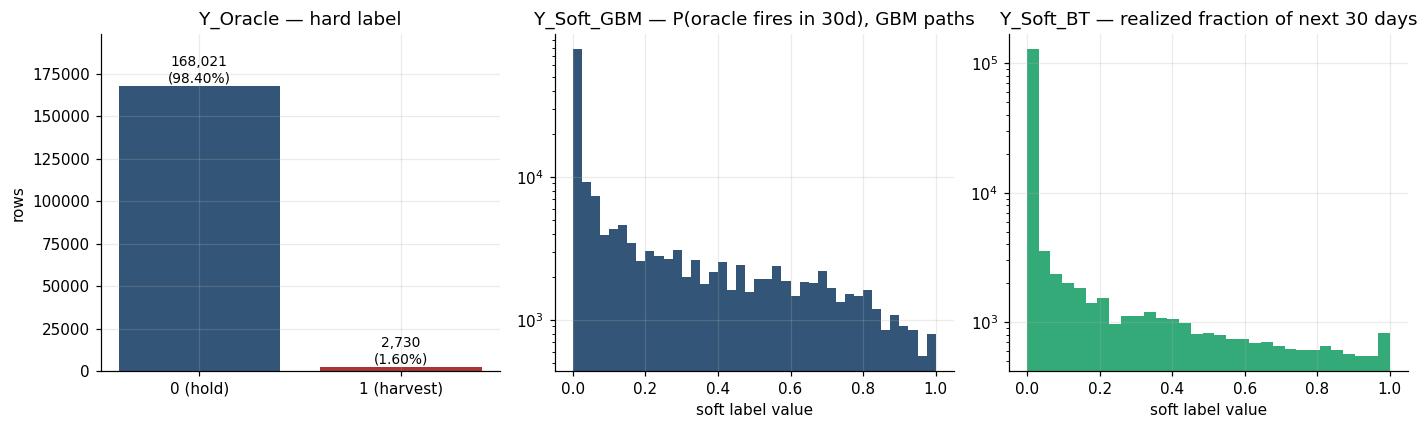

Y_Oracle = 1:                1.60% of rows
Y_Soft_GBM > 0:              65.04% of rows
Y_Soft_BT  > 0 (of non-NaN): 19.90% of rows


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Hard label: class balance.
counts = lots["Y_Oracle"].value_counts().sort_index()
bars = axes[0].bar(["0 (hold)", "1 (harvest)"], counts.values, color=["#357", "#a33"])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v/len(lots):.2%})",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].set_title("Y_Oracle — hard label")
axes[0].set_ylabel("rows")

# Soft labels: distributions on [0, 1].
axes[1].hist(lots["Y_Soft_GBM"], bins=40, color="#357")
axes[1].set_yscale("log")
axes[1].set_title("Y_Soft_GBM — P(oracle fires in 30d), GBM paths")
axes[1].set_xlabel("soft label value")

axes[2].hist(lots["Y_Soft_BT"].dropna(), bins=31, color="#3a7")
axes[2].set_yscale("log")
axes[2].set_title("Y_Soft_BT — realized fraction of next 30 days")
axes[2].set_xlabel("soft label value")

fig.tight_layout()
plt.show()

print(f"Y_Oracle = 1:                {lots['Y_Oracle'].mean():.2%} of rows")
print(f"Y_Soft_GBM > 0:              {(lots['Y_Soft_GBM'] > 0).mean():.2%} of rows")
print(f"Y_Soft_BT  > 0 (of non-NaN): {(lots['Y_Soft_BT'].dropna() > 0).mean():.2%} of rows")

The hard label is **severely imbalanced**: the oracle fires on only ~1.60% of lot-days in this early june 2024-2026 test case. That
is a natural result of the oracle's conditions that all four gates must be open at once. (In principle the gates also fight
each other where harvesting losses drains $G^{\mathrm{YTD}}$, closing the third gate; though in
this run the \$1M gains seed keeps $G^{\mathrm{YTD}}$ positive all year, so the rarity is
driven by the −2% loss gate and the wash-sale lockouts.) This single number drives most of
the methodology downstream: accuracy would be a useless metric (predicting "never harvest"
scores 98.4%), so model selection uses **PR-AUC** as the primary benchmark instead of **ROC-AUC**, with training using balanced class weights
and stratified splits.

Both soft labels pile up at 0 (note the logarithmic scaling) with a long right tail and a small spike
at 1 describes lots that are deep underwater and certain to stay harvestable all month. `Y_Soft_BT`
is the realized analogue of the Monte-Carlo `Y_Soft_GBM`, takes values in multiples of
$1/30$, and is noticeably *less* zero-heavy among its nonzero values: when a lot does become
harvestable on the real path, it tends to stay so for several of the next 30 days, while
independent GBM paths wash that persistence out. Binarized as `Y_Soft_BT > 0`, the modeling
target has a ~19.9% positive rate among labeled rows, still imbalanced, but an order of magnitude
friendlier than the hard label.

### Missing data

Missingness in this dataset is **structural, not accidental**, each missing cell is implied
by a definition, which is the most useful kind of missing data to have because it can be reasoned
about exactly.

,missing cells,pct
DeltaMA50,18,0.01
DeltaMA200,440,0.26
Y_Soft_BT,11162,6.54
Sector,961,0.56


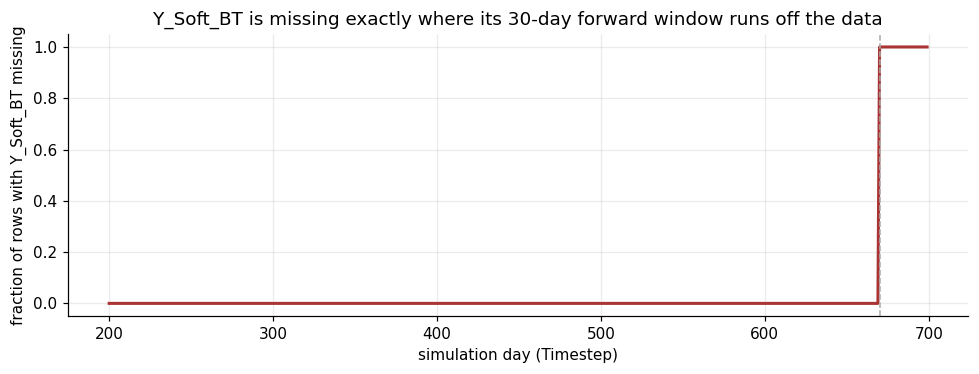

Sector value counts:
Sector
-          169790
<empty>       961
Name: count, dtype: int64

K (lots per ticker) unique values: [np.int64(1)]


In [4]:
na = lots.isna().sum()
display(na[na > 0].to_frame("missing cells").assign(
    pct=lambda d: (100 * d["missing cells"] / len(lots)).round(2)))

miss_by_t = lots.assign(m=lots["Y_Soft_BT"].isna()).groupby("Timestep")["m"].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(miss_by_t.index, miss_by_t.values, color="#a33", lw=2)
ax.axvline(lots["Timestep"].max() - 29, color="#aaa", ls="--", lw=1)
ax.set_xlabel("simulation day (Timestep)")
ax.set_ylabel("fraction of rows with Y_Soft_BT missing")
ax.set_title("Y_Soft_BT is missing exactly where its 30-day forward window runs off the data")
fig.tight_layout()
plt.show()

print("Sector value counts:")
print(lots["Sector"].fillna("<empty>").value_counts().head())
print(f"\nK (lots per ticker) unique values: {sorted(lots['K'].unique())}")

Three patterns, three explanations:

- **`Y_Soft_BT` (11,162 cells, 6.5%)** — the label is defined over the *next 30 trading
  days*, so the final 30 simulation days (Timesteps 670–699) cannot have it; the plot shows
  the missing rate snapping from 0 to 1 exactly at the cutoff. This is missing-by-design
  (the mechanism is known and depends only on `Timestep`, not on the unobserved value's
  *magnitude* — though rows near the end of a mostly-bullish window are not a random sample
  of market regimes, which is worth remembering). **Handling:** these rows are *excluded*
  from soft-label training and testing rather than imputed — imputing a label would
  manufacture ground truth. They remain available for the hard-label task, which is why the
  oracle models train on all 170,751 rows but the soft-label models on 159,589.
- **`DeltaMA50` / `DeltaMA200` (18 / 440 cells, <0.26%)** — a handful of tickers have price
  histories too short for the moving-average windows on their earliest days. **Handling:**
  median imputation, fit *inside each training fold only* (see
  [the recipe](#The-Recipe:-Feature-Handling)).
- **`Sector` (degenerate)** — 99.4% of rows carry the placeholder `"-"` and the rest are
  empty: the SPY holdings scrape does not populate sector in v0.1. The pipeline still cleans
  it (`"-"`/empty → `"Unknown"`) and one-hot encodes it, but the encoded feature is
  effectively constant and contributes nothing. We keep it in the recipe for schema
  honesty and flag it as a data-quality gap rather than silently dropping it.

The same check surfaces that **`K` (open lots per ticker) is constant at 1** in this run —
harvested lots are not re-bought into a second lot within the window — so two of the fifteen
numeric features (`K`, and `Sector` after encoding) carry no information. This explains a
zero eigenvalue we will meet again in the [PCA section](#Unsupervised-Structure).

### Outcome versus predictors

The oracle lives in $\mathbb{R^4}$ subset of the feature space whilst the models live in the full $\mathbb{R^{15}}$. The interesting question here is how much that extra dimensinailty (and therefore information) is actually contributing.

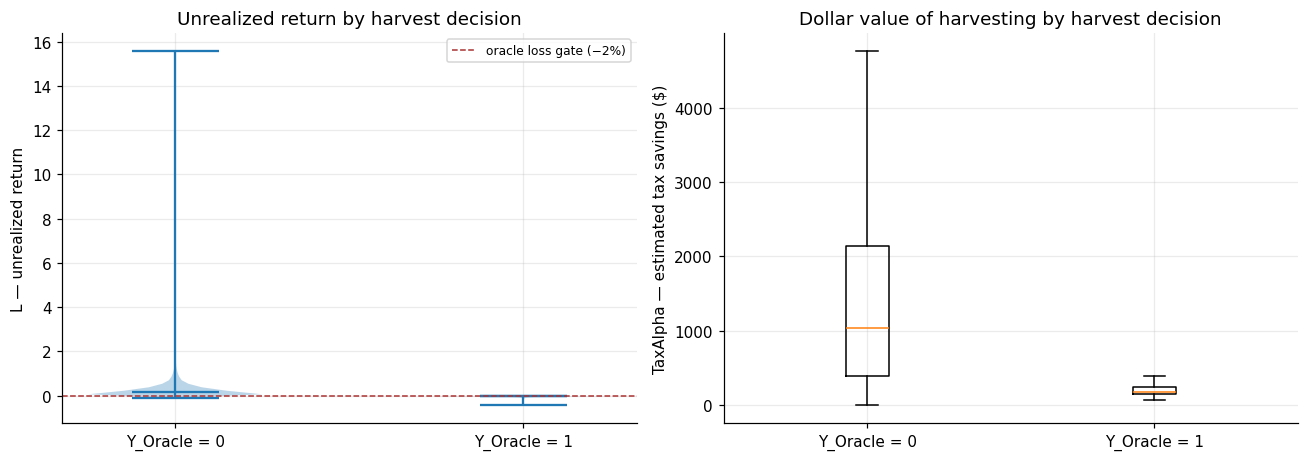

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# L by oracle decision — gate 1 made visible.
data_l = [lots.loc[lots["Y_Oracle"] == 0, "L"], lots.loc[lots["Y_Oracle"] == 1, "L"]]
parts = axes[0].violinplot(data_l, showmedians=True)
axes[0].axhline(-0.02, color="#a33", ls="--", lw=1, label="oracle loss gate (−2%)")
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["Y_Oracle = 0", "Y_Oracle = 1"])
axes[0].set_ylabel("L — unrealized return")
axes[0].set_title("Unrealized return by harvest decision")
axes[0].legend(fontsize=8)

# TaxAlpha by oracle decision (log scale; zeros dominate the negatives).
data_t = [lots.loc[lots["Y_Oracle"] == 0, "TaxAlpha"],
          lots.loc[lots["Y_Oracle"] == 1, "TaxAlpha"]]
axes[1].boxplot(data_t, tick_labels=["Y_Oracle = 0", "Y_Oracle = 1"], showfliers=False)
axes[1].set_ylabel("TaxAlpha — estimated tax savings ($)")
axes[1].set_title("Dollar value of harvesting by harvest decision")

fig.tight_layout()
plt.show()

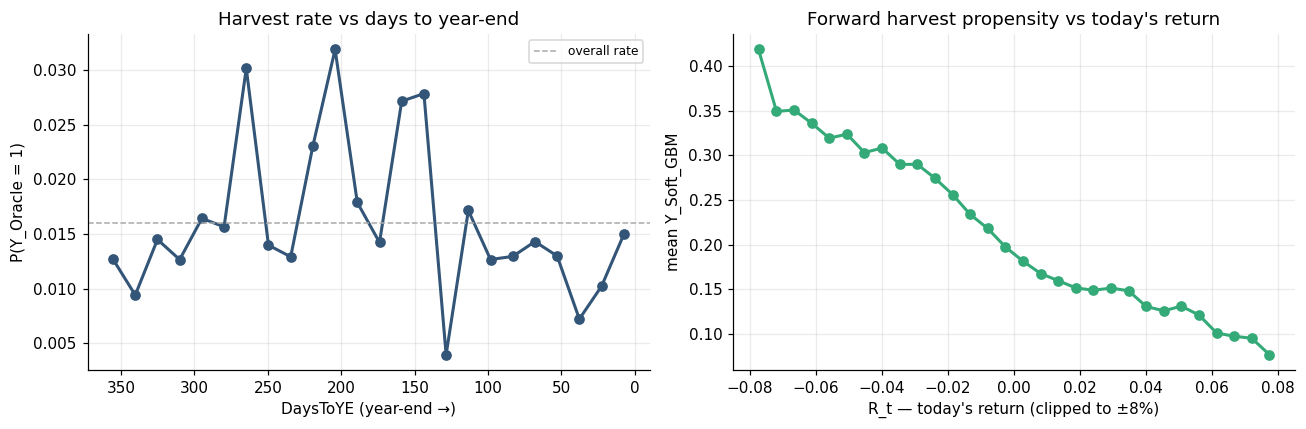

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Harvest rate as the year-end clock runs down.
bins = pd.cut(lots["DaysToYE"], bins=24)
rate = lots.groupby(bins, observed=True)["Y_Oracle"].mean()
mids = [iv.mid for iv in rate.index]
axes[0].plot(mids, rate.values, marker="o", color="#357", lw=2)
axes[0].axhline(lots["Y_Oracle"].mean(), color="#aaa", ls="--", lw=1, label="overall rate")
axes[0].invert_xaxis()
axes[0].set_xlabel("DaysToYE (year-end →)")
axes[0].set_ylabel("P(Y_Oracle = 1)")
axes[0].set_title("Harvest rate vs days to year-end")
axes[0].legend(fontsize=8)

# Soft label vs daily return, binned.
rbins = pd.cut(lots["R_t"].clip(-0.08, 0.08), bins=30)
rmean = lots.groupby(rbins, observed=True)["Y_Soft_GBM"].mean()
rmids = [iv.mid for iv in rmean.index]
axes[1].plot(rmids, rmean.values, marker="o", color="#3a7", lw=2)
axes[1].set_xlabel("R_t — today's return (clipped to ±8%)")
axes[1].set_ylabel("mean Y_Soft_GBM")
axes[1].set_title("Forward harvest propensity vs today's return")

fig.tight_layout()
plt.show()

The violin plot is the oracle's first gate drawn with data: harvested lots live entirely
below the −2% line while the hold class straddles it, with substantial mass *below* the line
too — lots with a deep enough loss where some *other* gate (wash-sale lock, TE budget)
blocked the harvest; with the \$1M seed the gains gate never closes in this window. That overlap is exactly why the hard-label task is learnable
but not trivial for a linear model: no single feature separates the classes; the boundary is
a *conjunction*. The `TaxAlpha` boxes tell the economic version of the same story — harvested
lots cluster around several hundred dollars of tax savings each ($\tau(H)\cdot|q_k(P_t-p_k)|$
with $\tau$ = 37% short-term / 20% long-term).

The year-end plot shows harvesting concentrating as `DaysToYE` shrinks — consistent with the
TLH folk wisdom that harvest opportunities are checked increasingly often late in the tax
year, though here the pattern emerges from gate dynamics (a year of accumulating
$G^{\mathrm{YTD}}$ and price drift) rather than any explicit calendar rule. The right panel
shows the forward-looking soft label rising steeply as today's return turns negative: a stock
falling today is far more likely to cross the −2% loss gate within 30 days. The relationship
is monotone but soft — today's return shifts the *probability*, it does not determine the
outcome — which is precisely the texture a good probabilistic classifier can exploit and a
hard threshold cannot.

### Correlation structure

Fifteen features from four conceptual families (lot, portfolio, asset, derived) — how much
do they overlap?

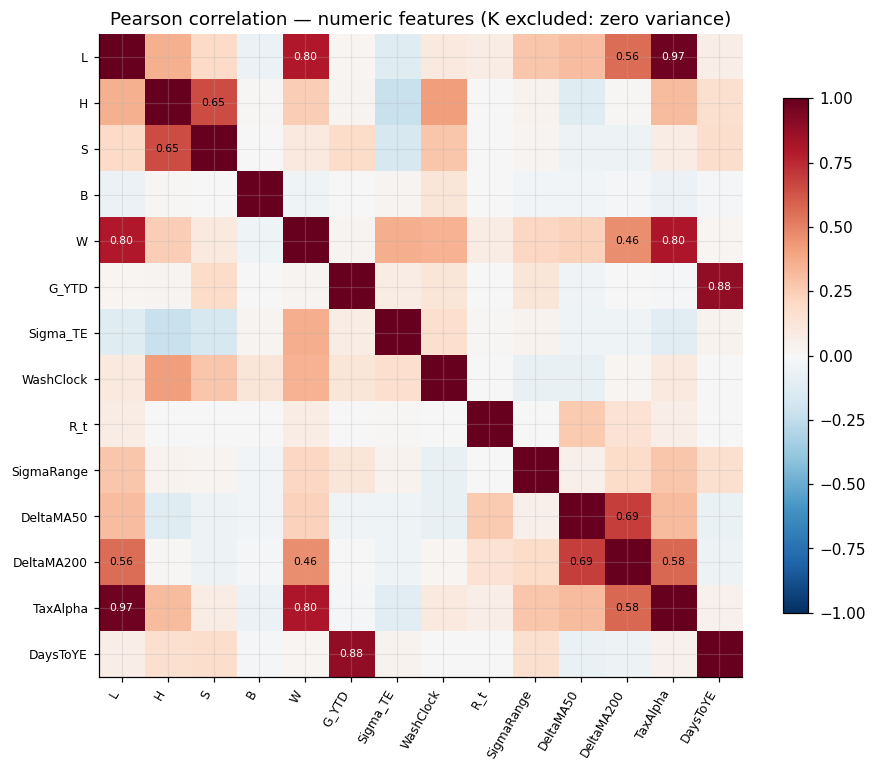

In [7]:
feat = [f for f in rh.NUMERIC_FEATURES if f != "K"]   # K is constant ⇒ correlation undefined
corr = lots[feat].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=8)
for i in range(len(feat)):
    for j in range(len(feat)):
        v = corr.iloc[i, j]
        if abs(v) > 0.45 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.7 else "black")
fig.colorbar(im, shrink=0.8)
ax.set_title("Pearson correlation — numeric features (K excluded: zero variance)")
fig.tight_layout()
plt.show()

The heatmap shows mostly moderate or no correlations at all: the feature families are genuinely
complementary with a few interpretable exceptions. `H` and `S` are strongly positively
correlated by definition ($S = \mathbb{1}[H \ge 365]$ is a deterministic step function of
`H`). `DeltaMA50` and `DeltaMA200` co-move (a stock above its 50-day average tends to be
above its 200-day average), and both correlate positively with `L`: all three are
denominated in "how far has this price drifted up," differing in baseline (cost basis vs
moving averages). The portfolio-level features `G_YTD`, `Sigma_TE`, and `DaysToYE` correlate
with each other through the shared calendar and state space in which they are constant across all lots within a day
and evolve slowly, a reminder (from `PortfolioMath.md` §3.5) that the rows are *conditionally*
independent given the features rather than i.i.d. draws. Nothing approaches the |0.95|+
territory that would force dropping a feature for the regularized linear models; elastic
net's L2 component comfortably absorbs this level of collinearity.

### The portfolio through time

A last sanity check on the simulation itself: when do harvests happen, and does the
gains-to-offset gate behave as designed?

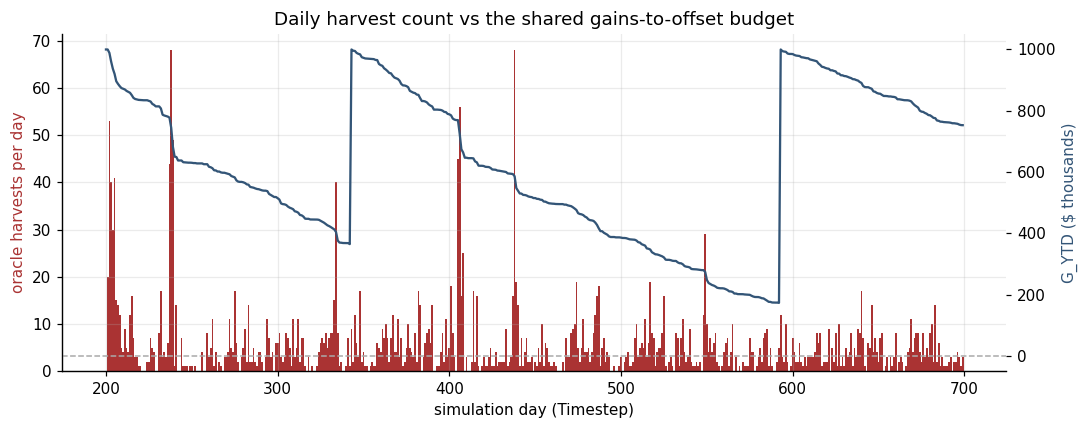

In [8]:
daily = lots.groupby("Timestep").agg(
    harvests=("Y_Oracle", "sum"), g_ytd=("G_YTD", "first"))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(daily.index, daily["harvests"], color="#a33", width=1.0, label="harvests (left)")
ax1.set_xlabel("simulation day (Timestep)")
ax1.set_ylabel("oracle harvests per day", color="#a33")
ax2 = ax1.twinx()
ax2.plot(daily.index, daily["g_ytd"] / 1e3, color="#357", lw=1.5, label="G_YTD (right)")
ax2.axhline(0, color="#aaa", lw=1, ls="--")
ax2.set_ylabel("G_YTD ($ thousands)", color="#357")
ax2.grid(False)
ax1.set_title("Daily harvest count vs the shared gains-to-offset budget")
fig.tight_layout()
plt.show()

Harvests arrive in bursts clusters of days where a market dip pushes many lots through
the loss gate simultaneously (the best example would be the market correction thats been happening for the past week but that will only realize after a month from now in which another spike is expected) where each burst visibly bites a step out of $G^{\mathrm{YTD}}$
(every harvest realizes a loss, reducing the budget). With the \$1M seed the budget never
actually reaches zero in this window, gate 3 stays open all year (the January re-seed is
the visible jump) but the depletion dynamic is exactly the self-limiting mechanism that
would throttle harvesting in a deeper drawdown. This self-limiting dynamic
is the main source of *label interactions across lots* — whether lot A is harvested today
affects whether lot B can be tomorrow. This is exactly why the portfolio state is encoded
into each row's features rather than left as a hidden confounder.

## Data Splitting and Cross-Validation

*(This section is written for readers new to machine learning)*

**Why split at all?** A model graded on the same data it studied is like a student graded on
the exact homework problems they memorized — the score says nothing about new problems. So
before any model sees the data, we lock **20% of rows away as a test set** and never touch it
during model development. All learning, tuning, and comparing happens on the remaining 80%
(the training set). The test set is opened once, at the very end, for the one or two models
we already decided are best.

**Why *stratified*?** Our positive class is rare (1.6% for the hard label). A careless
random split could, by bad luck, put most harvests in one side. Stratified splitting divides
each class *separately* — 80/20 within the positives and 80/20 within the negatives — so both
sides inherit the same class proportion. The implementation
(`src/ML/CSharp/MLNet/Splits/StratifiedSplit.cs`) shuffles each class with a seeded random
generator (seed 42, so the split is reproducible) and sends the first 20% of each class to
test.

**Why cross-validation?** Tuning a model means trying several hyperparameter settings and
keeping the best — but "best measured on what?" If we measured on the test set we would be
studying for the exam again. Instead, **5-fold cross-validation** chops the *training* set
into five equal folds (again stratified). For each candidate setting, the model trains on
four folds and is scored on the held-out fifth, rotating five times so every fold serves once
as the judge; the five scores are averaged. This way every tuning decision is validated on
data the model didn't train on, while the real test set stays sealed. The score being
averaged is **PR-AUC** (area under the precision–recall curve), chosen over the more common
ROC-AUC because with a rare positive class, ROC-AUC can look excellent while the model
drowns the few true positives in false alarms; PR-AUC penalizes exactly that.

One subtlety enforced throughout (`DataMemo/MLNetLeakageAudit.md`): every preprocessing
statistic — imputation medians, class weights, normalization means, one-hot vocabularies —
is computed on the **training portion of each fold only**, then applied unchanged to the
validation fold. The C# pipeline makes this structural: the fitting functions only *accept*
a training fold, so the leak cannot be written without changing function signatures.

In [9]:
gbt_soft = rh.load_artifact(ART, "gbt_soft_bt_metrics.json")
gbt_orc  = rh.load_artifact(ART, "gbt_oracle_metrics.json")

split_table = pd.DataFrame({
    "target": ["Y_Oracle (hard)", "Y_Soft_BT > 0 (soft)"],
    "usable rows": [gbt_orc["rowsTrain"] + gbt_orc["rowsTest"],
                    gbt_soft["rowsTrain"] + gbt_soft["rowsTest"]],
    "train (80%)": [gbt_orc["rowsTrain"], gbt_soft["rowsTrain"]],
    "test (20%)":  [gbt_orc["rowsTest"],  gbt_soft["rowsTest"]],
}).set_index("target")
display(split_table)

# Illustrate stratification: assign rows to 5 folds within each class, check the
# positive rate is preserved in every fold (the C# pipeline does the same per split).
rng = np.random.default_rng(42)
fold = np.empty(len(lots), dtype=int)
for cls, idx in lots.groupby("Y_Oracle").indices.items():
    idx = rng.permutation(idx)
    fold[idx] = np.arange(len(idx)) % 5
check = (pd.DataFrame({"fold": fold, "y": lots["Y_Oracle"]})
           .groupby("fold")["y"].agg(rows="count", positive_rate="mean"))
check["positive_rate"] = (100 * check["positive_rate"]).round(3).astype(str) + " %"
display(check)

,usable rows,train (80%),test (20%)
target,,,
Y_Oracle (hard),170751,136601,34150
Y_Soft_BT > 0 (soft),159589,127671,31918


,rows,positive_rate
fold,,
0,34151,1.599 %
1,34150,1.599 %
2,34150,1.599 %
3,34150,1.599 %
4,34150,1.599 %


The row counts differ between the two targets because the 11,162 rows with missing
`Y_Soft_BT` (the structural last-30-days gap from the [missing-data section](#Missing-data))
are excluded from the soft-label task. The fold check above demonstrates the point of
stratification: all five folds land within a hundredth of a percent of the same positive
rate, so no fold judges a model against an unusually easy or hard class mix.

## The Recipe: Feature Handling

All models share one preprocessing recipe, expressed as an ML.NET `EstimatorChain`
(the analogue of a tidymodels recipe or sklearn `Pipeline`), fit on training data only:

1. **Median imputation** — `DeltaMA50`/`DeltaMA200` NaNs are replaced with the
   training-fold median of each column (`MedianImputer.Fit(trainFold)`).
2. **Categorical encoding** — `Sector` is cleaned (`"-"`/empty → `"Unknown"`) and
   **one-hot encoded**, with the category vocabulary fit on the training fold; unseen
   categories at prediction time map to all-zeros. (As the EDA showed, in v0.1 the column is
   effectively constant — the machinery is exercised, the information content is nil.)
3. **Centering and scaling** — `NormalizeMeanVariance` standardizes every numeric feature to
   mean 0, variance 1, using training-fold statistics. This matters for the regularized
   linear models (logistic, elastic net, ridge), where penalties are scale-sensitive:
   unscaled, a feature denominated in dollars (`B`, `G_YTD`) would be penalized into
   irrelevance next to one in fractions (`L`, `R_t`). Tree ensembles are scale-invariant, but
   the same normalization is applied anyway — quoting the pipeline's own artifact note:
   *"NormalizeMeanVariance applied for schema consistency; scale-invariant for trees."*
4. **Class weighting** — each training row gets weight inversely proportional to its class
   frequency (`ClassWeights.AttachBalancedWeights`), so the rare positives are not ignored
   by loss minimization. With a 1.6% positive rate this weight is roughly 30:1.
5. **Assembly** — the fifteen numeric features and the one-hot sector concatenate into a
   single feature vector; `Symbol` and `Timestep` are metadata and never enter the model;
   the labels obviously never appear among the inputs.

The outcome is then modeled as a function of this feature vector — binary classification of
`Y_Oracle` or of `Y_Soft_BT > 0`, plus one deliberately mis-specified linear *regression* on
the continuous `Y_Soft_BT` kept as a cautionary comparison.

## Model Fitting and Tuning

Five model types were fit: four serious classifiers spanning the linear-to-ensemble
spectrum, plus the linear-regression demonstration (model menu debated in repo issue
[#4](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/4); the ML.NET implementation
landed in PR [#11](https://github.com/ieatyoursushi/DirectIndexing_ML/pull/11) after issue
[#10](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/10) retired the Python
training path). Every tunable hyperparameter was tuned by grid search, each configuration
scored by mean PR-AUC across the stratified 5-fold CV described above:

| Model | What it does | Grid searched |
|---|---|---|
| **Logistic regression (L2)** | Linear decision boundary through a sigmoid; the classical baseline | inverse regularization $C \in \{0.01, 0.1, 1, 10\}$ |
| **Elastic net (logistic)** | Linear boundary with both L1 (sparsity) and L2 (shrinkage) penalties | $\lambda_{L1} \times \lambda_{L2}$, 3 × 3 grid |
| **Random forest** | Many decorrelated trees vote; averages away single-tree variance | trees $\in \{100, 200\}$ × leaves $\in \{20, 31\}$ |
| **Gradient boosted trees** | Trees built sequentially, each correcting its predecessors' errors | trees $\in \{100, 200\}$ × learning rate $\in \{0.05, 0.1\}$ × leaves $\in \{20, 31\}$ |
| **Linear regression (ridge)** | Fits the *continuous* soft label by least squares — included to show why regression is the wrong tool for a probability | $\lambda_{L2}$, 3 values |

Both targets get the full treatment: the **oracle target** as the recoverability sanity
check, and the **soft target** as the real target / primary classification benchmark in this version of the project.

In [10]:
lb_soft = rh.load_artifact(ART, "soft_bt_cv_leaderboard.json")
lb_orc  = rh.load_artifact(ART, "oracle_cv_leaderboard.json")

print("Cross-validation leaderboard — target = Y_Soft_BT > 0")
display(rh.leaderboard_df(lb_soft).style.format(
    {"mean CV PR-AUC": "{:.4f}", "fold std": "{:.4f}"}).hide(axis="index"))

print("Cross-validation leaderboard — target = Y_Oracle")
display(rh.leaderboard_df(lb_orc).style.format(
    {"mean CV PR-AUC": "{:.4f}", "fold std": "{:.4f}"}).hide(axis="index"))

Cross-validation leaderboard — target = Y_Soft_BT > 0


model,type,mean CV PR-AUC,fold std,configs tried,champion
Gradient Boosted Trees,classifier,0.8576,0.0045,8,★
Random Forest,classifier,0.6940,0.0059,4,★
Logistic Regression (L2),classifier,0.6496,0.0084,4,
Elastic Net,classifier,0.6346,0.0090,9,
Linear Regression,regression_demonstration,0.5594,0.0098,3,


Cross-validation leaderboard — target = Y_Oracle


model,type,mean CV PR-AUC,fold std,configs tried,champion
Gradient Boosted Trees,classifier,0.9997,0.0004,8,★
Random Forest,classifier,0.9987,0.0018,4,★
Logistic Regression (L2),classifier,0.9867,0.0061,4,
Elastic Net,classifier,0.4418,0.0243,9,
Linear Regression,regression_demonstration,0.3715,0.0219,3,


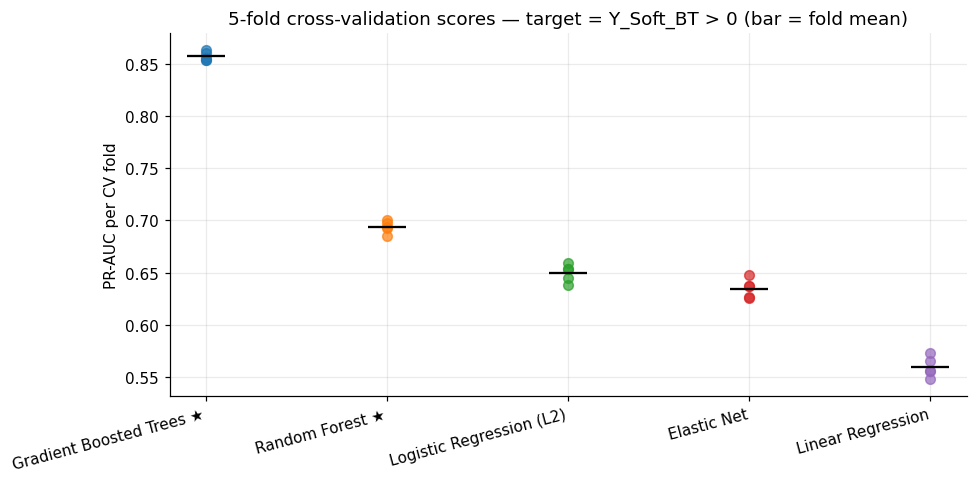

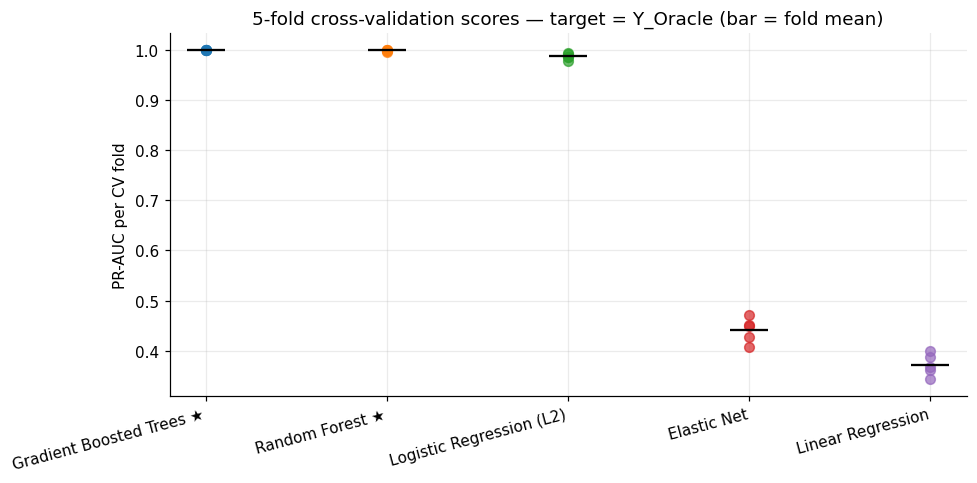

In [11]:
fig = rh.plot_cv_folds(lb_soft, "Y_Soft_BT > 0")
plt.show()
fig = rh.plot_cv_folds(lb_orc, "Y_Oracle")
plt.show()

This EDA-visiual brings clarity to the difference between the models and their test deviations: every model's
five folds cluster tightly (fold-to-fold standard deviations of well under 0.02), so the
ranking is not an artifact of one lucky fold, the gaps between models dwarf the spread
within them.

Two findings stand out: On the **soft target (or oracle data-structure target)**, there is a three-tier structure: gradient
boosting (0.858) far ahead, random forest (0.694) in the middle, and the linear models at
0.56–0.65. Within the linear tier, plain logistic (0.650) edges out elastic net (0.635) —
the extra L1 penalty only removes capacity the model needs — and both sit ~0.21 of PR-AUC
below the boosted trees: "will this lot become harvestable within 30 days?" depends on
interactions (a loss near the gate *and* slack in the TE budget *and* wash-sale clearance)
that no weighted sum of features can fully express, which is far more fitting of a tree based model that encodes conditions/decisions.

The **oracle target** is more subtle, and more interesting. The tree ensembles essentially
solve it (PR-AUC ≥ 0.999) since the label is a conjunction of four
axis-aligned thresholds, literally a depth-4 decision tree. But plain logistic also lands
high (0.987), which seems to contradict the "a hyperplane cannot express an AND" argument —
until you notice *which gates actually bind in this run*. With the \$1M gains seed,
$G^{\mathrm{YTD}} > 0$ holds on **100% of rows** (the EDA's temporal plot shows the budget
never reaching zero), and the tracking-error and wash-sale gates pass most of the time — so
the effective decision boundary nearly collapses to the single half-space $L \le -0.02$,
which a logistic model expresses exactly. Elastic net (0.442) and least squares (0.372)
still fail: the elastic net's penalties shrink the one coefficient that matters, and least
squares is structurally miscalibrated. The lesson is sharper than the original story: the
oracle's *geometry* is not fixed as in how non-linear the problem is depends on how many of its
gates actually bind, which is set by the gains-budget calibration.

### Tuning results per model

The grids below show every configuration's mean CV PR-AUC on the soft target (the tables are
read directly from the ML.NET-layer produced tuning artifacts; the oracle-target grids behave analogously with
compressed differences).

In [12]:
for key in ("gbt", "rf", "elnet", "logistic", "linreg"):
    print(f"--- {rh.MODEL_NAMES[key]} — grid search, target = Y_Soft_BT > 0")
    display(rh.tuning_table(rh.lb_entry(lb_soft, key)).style.format(
        {"mean CV PR-AUC": "{:.4f}"}).hide(axis="index"))

--- Gradient Boosted Trees — grid search, target = Y_Soft_BT > 0


numberOfTrees,learningRate,numberOfLeaves,mean CV PR-AUC
200,0.100000,31,0.8576
200,0.100000,20,0.8257
200,0.050000,31,0.8152
100,0.100000,31,0.8141
200,0.050000,20,0.7916
100,0.100000,20,0.7911
100,0.050000,31,0.7792
100,0.050000,20,0.7626


--- Random Forest — grid search, target = Y_Soft_BT > 0


numberOfTrees,numberOfLeaves,mean CV PR-AUC
100,31,0.6940
200,31,0.6933
100,20,0.6800
200,20,0.6795


--- Elastic Net — grid search, target = Y_Soft_BT > 0


l1Regularization,l2Regularization,mean CV PR-AUC
0.010000,0.001000,0.6346
0.100000,0.001000,0.6344
0.001000,0.001000,0.6318
0.001000,0.010000,0.6030
0.010000,0.010000,0.6021
0.100000,0.010000,0.5983
0.100000,0.100000,0.5544
0.010000,0.100000,0.5521
0.001000,0.100000,0.5521


--- Logistic Regression (L2) — grid search, target = Y_Soft_BT > 0


C,mean CV PR-AUC
10.000000,0.6496
1.000000,0.6477
0.100000,0.6405
0.010000,0.6327


--- Linear Regression — grid search, target = Y_Soft_BT > 0


l2Regularization,mean CV PR-AUC
0.010000,0.5594
0.001000,0.5585
0.000100,0.5492


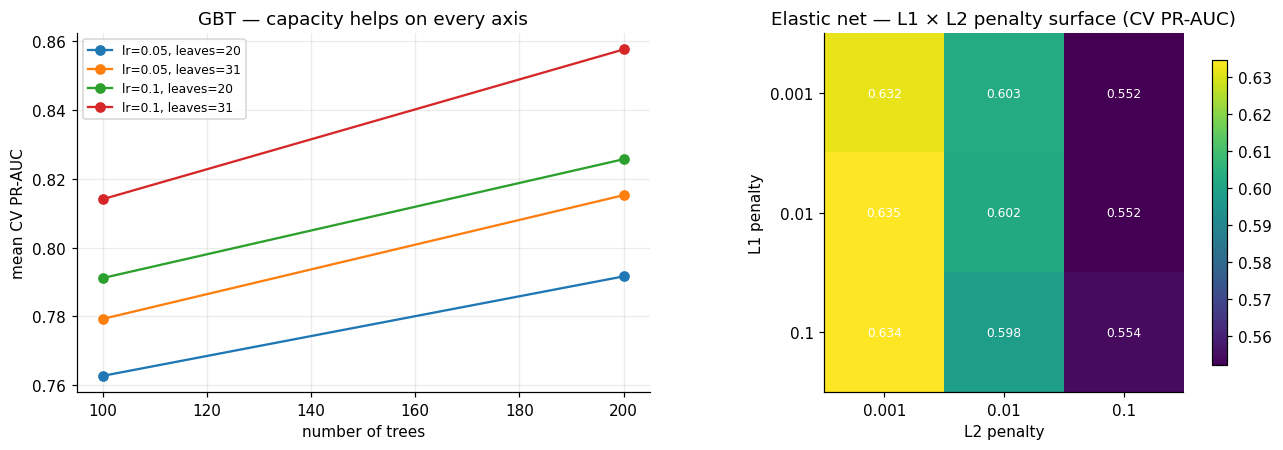

In [13]:
# Tuning curves for the two models where hyperparameters actually moved the needle.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

gbt_tbl = rh.tuning_table(rh.lb_entry(lb_soft, "gbt"))
for (lr, lv), grp in gbt_tbl.groupby(["learningRate", "numberOfLeaves"]):
    grp = grp.sort_values("numberOfTrees")
    axes[0].plot(grp["numberOfTrees"], grp["mean CV PR-AUC"], marker="o",
                 label=f"lr={lr}, leaves={lv}")
axes[0].set_xlabel("number of trees"); axes[0].set_ylabel("mean CV PR-AUC")
axes[0].set_title("GBT — capacity helps on every axis")
axes[0].legend(fontsize=8)

el_tbl = rh.tuning_table(rh.lb_entry(lb_soft, "elnet"))
piv = el_tbl.pivot(index="l1Regularization", columns="l2Regularization",
                   values="mean CV PR-AUC")
im = axes[1].imshow(piv.values, cmap="viridis")
axes[1].set_xticks(range(len(piv.columns))); axes[1].set_xticklabels(piv.columns)
axes[1].set_yticks(range(len(piv.index)));   axes[1].set_yticklabels(piv.index)
axes[1].set_xlabel("L2 penalty"); axes[1].set_ylabel("L1 penalty")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[1].text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center",
                     color="white", fontsize=8)
axes[1].set_title("Elastic net — L1 × L2 penalty surface (CV PR-AUC)")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], shrink=0.85)
fig.tight_layout()
plt.show()

The two panels tell complementary tuning stories. For **GBT**, every capacity knob helps:
more trees, more leaves, and the larger learning rate each lift CV PR-AUC, from 0.76 at the
smallest configuration to 0.858 at the largest (200 trees, rate 0.1, 31 leaves — the chosen
config, sitting at the grid's edge, which suggests issue
[#18](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/18)'s follow-up of widening
the grid could buy a little more). For **elastic net**, the penalty surface slopes toward
the weak-penalty corner (best: $\lambda_1 = 0.01$, $\lambda_2 = 0.001$, with ~0.08 of
PR-AUC separating the strongest and weakest penalties) — regularization only costs this
model capacity, the same message logistic sends by choosing its weakest penalty ($C = 10$).
Random forest preferred 100 trees × 31 leaves, and the ridge regression's three $\lambda$
values were nearly indistinguishable.

## Model Selection and Test-Set Performance

Only the **two CV champions: gradient boosted trees and random forest** advance to the
sealed test set; the linear models' CV scores eliminated them without spending test data
(the ridge-regression demonstration is reported separately below). Test metrics come from
each champion's final refit on the full 80% training split.

Test-set performance — target = Y_Soft_BT > 0


,test ROC-AUC,test PR-AUC,F1 @ 0.5,F1 @ best threshold,best threshold
model,,,,,
Gradient Boosted Trees,0.9641,0.8615,0.7618,0.7933,0.6848
Random Forest,0.9096,0.6969,0.6426,0.6747,31.3748


Test-set performance — target = Y_Oracle


,test ROC-AUC,test PR-AUC,F1 @ 0.5,F1 @ best threshold,best threshold
model,,,,,
Gradient Boosted Trees,1.0000,0.9993,0.9973,0.9973,0.7392
Random Forest,0.9999,0.9932,0.9954,0.9954,111.4962


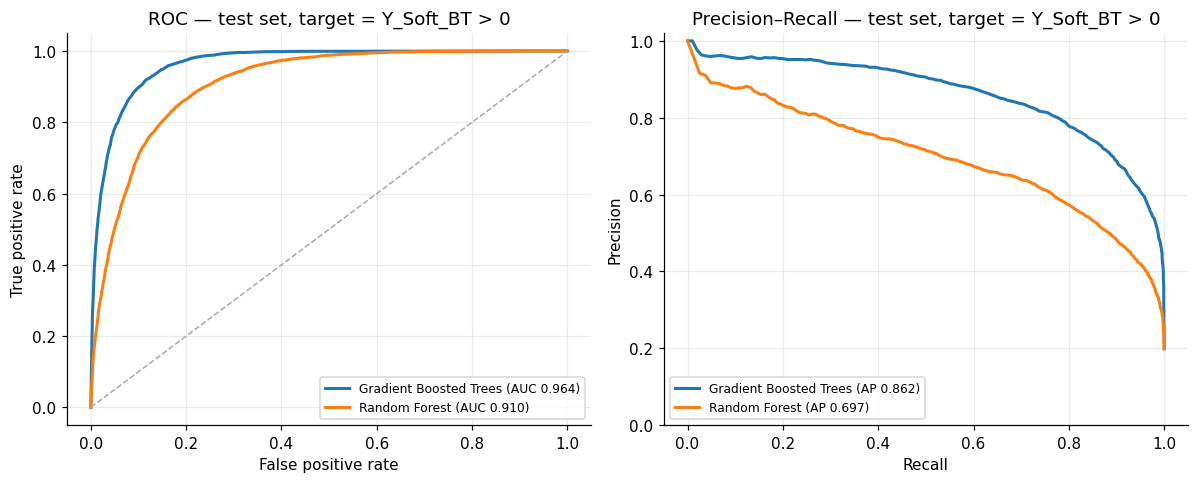

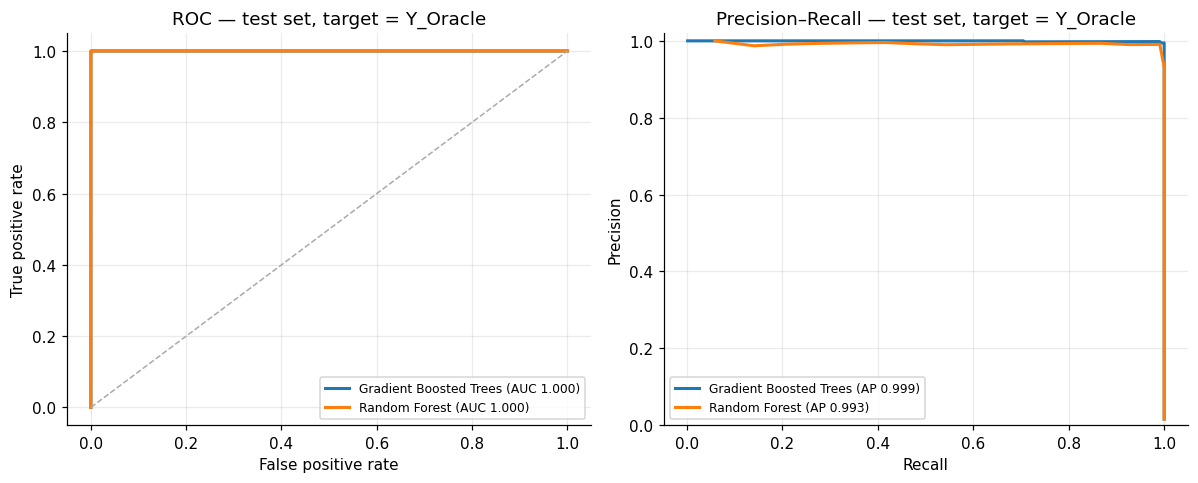

In [14]:
rf_soft = rh.load_artifact(ART, "rf_soft_bt_metrics.json")
rf_orc  = rh.load_artifact(ART, "rf_oracle_metrics.json")

champs_soft = {"gbt": gbt_soft, "rf": rf_soft}
champs_orc  = {"gbt": gbt_orc,  "rf": rf_orc}

print("Test-set performance — target = Y_Soft_BT > 0")
display(rh.test_metrics_table(champs_soft).style.format("{:.4f}"))
print("Test-set performance — target = Y_Oracle")
display(rh.test_metrics_table(champs_orc).style.format("{:.4f}"))

fig = rh.plot_roc_pr_overlay(champs_soft, "Y_Soft_BT > 0")
plt.show()
fig = rh.plot_roc_pr_overlay(champs_orc, "Y_Oracle")
plt.show()

On the real (soft) task the **gradient boosted ensemble generalizes slightly better than it
cross-validated** a test PR-AUC 0.862 vs CV 0.858, signature of a model that
was well-tuned as in nothing was overfit to the folds. The ROC panel shows both models high
(0.96 / 0.91), but the PR panel is where the ranking earns its keep: GBT holds its precision
much deeper into the recall range while the forest's decays sooner; at equal recall, the
forest raises substantially more false alarms. (A note on the forest's odd "best threshold"
of ~31: ML.NET's random forest emits uncalibrated vote scores rather than probabilities, so
its threshold lives on the vote scale, the ranking metrics are unaffected.)

On the oracle target both champions score perfectly to three decimals, confirming the
boundary-recovery sanity check of these fundamentally tree-decision-based models.

The confusion matrices below make the soft-target trade-off concrete at two operating
points: the default 0.5 cutoff and the F1-maximizing cutoff (0.685 for GBT).

In [15]:
print(f"GBT, soft target — threshold 0.5 (left) vs F1-optimal {gbt_soft['bestThreshold']:.3f} (right)")
left  = rh.confusion_df(gbt_soft, "confusionAt05")
right = rh.confusion_df(gbt_soft, "confusionAtBest")
display(pd.concat({"threshold = 0.5": left, "best threshold": right}, axis=1))

c = gbt_soft["confusionAtBest"]
prec = c["tp"] / (c["tp"] + c["fp"]); rec = c["tp"] / (c["tp"] + c["fn"])
print(f"At the F1-optimal threshold: precision {prec:.1%}, recall {rec:.1%}")

GBT, soft target — threshold 0.5 (left) vs F1-optimal 0.685 (right)


threshold = 0.5             best threshold            
             predicted 0 predicted 1    predicted 0 predicted 1
actual 0           22358        3208          23855        1711
actual 1             470        5882           1051        5301

At the F1-optimal threshold: precision 75.6%, recall 83.5%


At the default cutoff the model is recall-greedy: it catches 5,882 of 6,352 soon-harvestable
lots (93%) but flags 3,208 false alarms. Raising the cutoff to 0.685 trades 581 of those
catches for a 47% drop in false alarms (precision 65% → 76%, recall 93% → 83%). Which point
is "better" is an economic question, not a statistical one: a false negative is a missed tax
saving (a few hundred dollars of `TaxAlpha` per the EDA), while a false positive in a real
system means a needless trade — transaction costs, a consumed wash-sale window, and
tracking-error budget.
Since wash-sale lockouts compound across the portfolio, the high-precision operating point
is the more defensible default for production, and threshold-vs-tax-alpha optimization is
flagged as post-course work in issue
[#12](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/12).

### The cautionary tale: regression on a probability (optional)

Ridge regression was fit on the *continuous* `Y_Soft_BT` — deliberately the wrong tool, kept
in the lineup to show *why* it is wrong rather than assert it. To be precise about test-set
discipline: only the **two CV champions above** were evaluated on the test set for model
selection and performance claims. The ridge model was eliminated by its CV score like the
other linear models; the held-out diagnostic below (the fraction of its predictions falling
outside $[0,1]$) is reported purely as a pedagogical exhibit of *why* regression is the
wrong tool for a probability, not as a candidate's test performance.

In [16]:
linreg = rh.load_artifact(ART, "linreg_soft_bt_metrics.json")
print(f"CV PR-AUC (score ranked as if a probability): {linreg['cvBestMeanPrAuc']:.3f}")
print(f"Predictions outside [0, 1]: {linreg['fractionOutsideUnit']:.1%} "
      f"(mean prediction {linreg['meanPrediction']:.4f}, bias {linreg['bias']:.4f})")

coefs = pd.read_csv(ART / "linreg_soft_bt_coefficients.csv")
display(coefs.reindex(coefs["coefficient"].abs().sort_values(ascending=False).index)
        .head(8).style.format({"coefficient": "{:.3f}"}).hide(axis="index"))

CV PR-AUC (score ranked as if a probability): 0.560
Predictions outside [0, 1]: 10.1% (mean prediction 0.4030, bias 0.6313)


feature,coefficient
H,-0.392
Sigma_TE,-0.141
DeltaMA50,-0.099
G_YTD,0.090
Sector_0,0.083
DeltaMA200,-0.083
S,0.061
SigmaRange,0.055


The failure is structural, not a tuning problem: least squares happily predicts values
outside $[0,1]$ (the artifact records the offending fraction), because nothing in the
squared-error objective knows the target is a probability. Treating its raw score as a
ranking still only reaches PR-AUC ≈ 0.56 — worst in the lineup. The standardized
coefficients are still a useful free interpretability read on *linear* signal direction: the
model leans hardest on `H` (negative — in a rising market, long-held lots sit on gains, far
from the loss gate), `Sigma_TE` (negative — a strained tracking-error budget blocks the
oracle), and `DeltaMA50` (negative — a price above its moving average is moving away from
harvestability), consistent with the gate structure. The logistic model's
coefficients (also exported by the pipeline) tell the same directional story through a
proper probabilistic link.

## Unsupervised Structure

Two unsupervised methods were run on the standardized features (fit on the training split
only, per the leakage audit) — PCA to measure effective dimensionality, k-means to ask
whether lot-states cluster naturally.

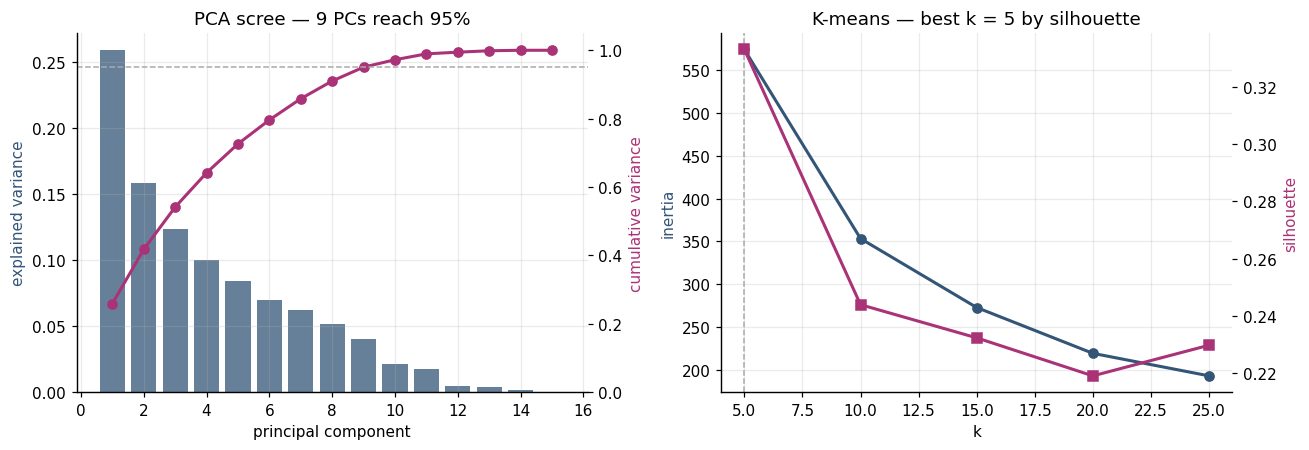

In [17]:
scree = rh.load_artifact(ART, "pca_scree.json")
elbow = rh.load_artifact(ART, "kmeans_elbow.json")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ks, ev, cv = scree["k"], scree["explainedVariance"], scree["cumulativeVariance"]
axes[0].bar(ks, ev, color="#357", alpha=0.75)
ax0b = axes[0].twinx()
ax0b.plot(ks, cv, color="#a37", marker="o", lw=2)
ax0b.axhline(scree["threshold"], color="#aaa", ls="--", lw=1)
ax0b.set_ylim(0, 1.05); ax0b.grid(False)
ax0b.set_ylabel("cumulative variance", color="#a37")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance", color="#357")
axes[0].set_title(f"PCA scree — {scree['nKept']} PCs reach {scree['threshold']:.0%}")

axes[1].plot(elbow["ks"], elbow["inertia"], color="#357", marker="o", lw=2)
ax1b = axes[1].twinx()
ax1b.plot(elbow["ks"], elbow["silhouette"], color="#a37", marker="s", lw=2)
ax1b.set_ylabel("silhouette", color="#a37"); ax1b.grid(False)
axes[1].axvline(elbow["bestK"], color="#aaa", ls="--", lw=1)
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia", color="#357")
axes[1].set_title(f"K-means — best k = {elbow['bestK']} by silhouette")

fig.tight_layout()
plt.show()

The screen plot says the feature space is **genuinely high-dimensional**: the first component
explains only 26% of variance and it takes nine of the fifteen components to clear the 95%
threshold. There is essentially no two-dimensional summary hiding inside as similarly explaind by the feature correlation matrix. The fifteenth eigenvalue is numerically zero, the
algebraic echo of the constant `K` column found in the EDA. K-means prefers the smallest
$k$ tried ($k=5$, silhouette ≈ 0.33 and falling with $k$), weak clustering overall, which
makes sense for data that is a smooth panel of market states rather than a mixture of
distinct regimes.

## Conclusion / TLDR

This project set out to learn the tax-loss-harvest decision at lot-level, with the
results splitting cleanly for the two research questions. On the sanity check, recovering the
deterministic oracle, the tree ensembles were essentially perfect (test PR-AUC 0.999/0.993),
and the pattern of linear performance turned out to be the more instructive result: plain
logistic nearly solved it too (CV 0.987), because with the \$1M gains seed the
$G^{\mathrm{YTD}}$ gate never closes and the four-gate conjunction effectively collapses to
a single loss threshold, while elastic net (0.442) and least squares (0.372) still failed.
A conjunction is only as non-linear as the number of gates that actually bind. On the real
question of predicting whether a lot becomes harvestable within 30 days, **gradient boosted
trees won without a question**: 0.858 CV PR-AUC, 0.862 on the sealed test set against a 19.9% base
rate, with 76% precision at 83% recall at the tuned operating point. Random forests took a
clear second (0.694); the linear tier sat at 0.56–0.65, consistently preferring its weakest
penalties; and ridge regression on the continuous label failed in the instructive way,
sending 10% of its predictions outside $[0,1]$. In the CAPM framing of the introduction, the
champion is the machinery behind the strategy's one-line promise -> *hold
$\hat\beta_{DI} \approx 1$, harvest $\alpha$ from the tax code*: it ranks lots by expected
harvestability so that $\alpha_{\text{tax}}$ can be collected while the tracking-error gate
keeps the index estimator relatively stable to the index's movements.

Two results genuinely suprising (as talked about in office hours): First, the **size of the GBT–RF gap** (0.16 of PR-AUC):
both are tree ensembles with similar capacity per tree, but boosting's sequential
error-correction evidently matters enormously when the positive class lives in a thin,
sharply-bounded region rather than averaging independent trees which is less goal-oriented. Second, **how much the oracle's geometry depends on calibration**: under
an earlier 5% (\$500K) gains seed the budget was exhausted mid-year, all four gates bound,
and every linear model collapsed on the oracle target; recalibrating the seed to the index's
~10% historical return left the gains gate permanently open and made the boundary nearly
linear. The models did not change but the *economics* did, and the difficulty moved with it.
Meanwhile the champion's near-identical CV and test scores (0.858 / 0.862) say the soft
target's predictable signal is stable across folds and the held-out set.

The honest caveats double as the roadmap. The labels are **semi-synthetic** (real prices,
simulated portfolio), the window is a single, mostly-bullish two-year span, the `Sector`
column is degenerate and `K` constant in this run, and the random split's conditional-
independence argument leans on the portfolio state being encoded in the features, a
**walk-forward temporal split** (train on year one, test on year two) is the natural
robustness check and is queued as post-course task. Beyond that, the next steps tracked in
the repository are richer soft-label families (issue
[#17](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/17)), longer price history
(issue [#19](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/19)), portfolio-level
economic evaluation, translating confusion matrices into realized tax alpha net of
tracking error (issue [#12](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/12)) 
and, further out, Marchenko–Pastur covariance cleaning for the tracking-error model (issue
[#5](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/5)) and a reinforcement-learning policy layer that acts on these predictions (issue
[#15](https://github.com/ieatyoursushi/DirectIndexing_ML/issues/15)). Within the scope this
course, the central conclusion stands that the harvest decision boundary is
learnable, its 30-day forward propensity is largely predictable from current state, and
gradient boosted trees are the right tool for both for the current bullish market-schema obserevd.

## References and Reproducibility

**Data**

- Financial Modeling Prep. (2026). *Historical Price EOD API* [Data set]. Retrieved June
  2026, from https://financialmodelingprep.com/
- State Street Global Advisors. (2026). *SPDR S&P 500 ETF Trust (SPY) Daily Holdings*
  [Data set]. Retrieved June 2026, from https://www.ssga.com/

**Methodology background**

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to
  Statistical Learning* (2nd ed.). Springer. (Cross-validation, tree ensembles, PCA.)
- Internal Revenue Service. (2025). *Publication 550: Investment Income and Expenses* —
  wash-sale rule. https://www.irs.gov/publications/p550
- Project mathematical memos: `DataMemo/SimulationMath.md`, `DataMemo/PortfolioMath.md`,
  `DataMemo/MLNetLeakageAudit.md`, in the
  [project repository](https://github.com/ieatyoursushi/DirectIndexing_ML).

**LLM use citation (per course policy).** Claude (Anthropic) was used as a coding
assistant for **code portions** of this project: portions of the C# simulation and ML.NET
layers (see the co-authorship notes in `DataMemo/`), the Python report-layer scripts
(`scripts/report.py`, `scripts/codebook.py`, `scripts/report_helpers.py`,
`scripts/dependencies.py`, `scripts/package_submission.py`), and the code cells of this
notebook. All AI-assisted code was reviewed, tested, and is documented in the repository's
commit history. A full methodology statement — division of labor, file-level scope, and the
verification process — is included with this submission as `AI_USAGE.md`.

**Reproducing this report** (commands run from `src/`; .NET 8 and
[uv](https://docs.astral.sh/uv/) required):

```text
export FMP_API_KEY=...      # only needed to re-download raw prices
dotnet run download         # layer 1 — fetch prices + constituents
dotnet run simulate         # layer 2 — backtest, writes data/lots.csv
dotnet run mlnet-all        # layer 3 — CV all models, test champions, write artifacts
dotnet run report           # layer 4 — codebook + execute this notebook + export HTML
dotnet run submission       # package the course submission zip
```

In [18]:
import sys, matplotlib, json
print("software versions:")
print("  python    ", sys.version.split()[0])
for mod in (pd, np, matplotlib):
    print(f"  {mod.__name__:<10}", mod.__version__)
print("  ML.NET     3.0.1 (C# training pipeline)")

software versions:
  python     3.14.2
  pandas     3.0.3
  numpy      2.4.6
  matplotlib 3.10.9
  ML.NET     3.0.1 (C# training pipeline)
